In [1]:
import pandas as pd
adult = pd.read_csv("./datasets/adult.csv")
adult.head()

,Age,Workclass,fnlgwt,Education,Education Num,Marital Status,Occupation,Relationship,Race,Sex,Capital Gain,Capital Loss,Hours/Week,Country,Above/Below 50k
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [2]:
adult.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              32561 non-null  int64
 1   Workclass        32561 non-null  str  
 2   fnlgwt           32561 non-null  int64
 3   Education        32561 non-null  str  
 4   Education Num    32561 non-null  int64
 5   Marital Status   32561 non-null  str  
 6   Occupation       32561 non-null  str  
 7   Relationship     32561 non-null  str  
 8   Race             32561 non-null  str  
 9   Sex              32561 non-null  str  
 10  Capital Gain     32561 non-null  int64
 11  Capital Loss     32561 non-null  int64
 12  Hours/Week       32561 non-null  int64
 13  Country          32561 non-null  str  
 14  Above/Below 50k  32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


# Intro

## Using describe
- Use `df['col'].describe()` on a categorical column to get count of values, num of unique values, mode, and frequency of modal observation (vs. summary stats and 5 number summary when used on numerical columns)

In [3]:
adult["Marital Status"].describe()

count                   32561
unique                      7
top        Married-civ-spouse
freq                    14976
Name: Marital Status, dtype: object

## Using value counts
- Prints frequency table of observations
- Set kwarg `normalize=True` to get relative frequencies

In [4]:
adult["Marital Status"].value_counts()

Marital Status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64

# Categorical data in pandas

## dtypes: object
- By default, pandas infers datatypes of each column.
- Pandas *has* a categorical datatype
    - Convert to categorical using `df['col'].astype("category")`
- Note: to check datatype of a series (ie. how a column is returned), use `df['col'].dtype` NOT THE SAME as `df.dtypes()`

In [5]:
adult.dtypes

Age                int64
Workclass            str
fnlgwt             int64
Education            str
Education Num      int64
Marital Status       str
Occupation           str
Relationship         str
Race                 str
Sex                  str
Capital Gain       int64
Capital Loss       int64
Hours/Week         int64
Country              str
Above/Below 50k      str
dtype: object

In [6]:
adult["Marital Status"] = adult["Marital Status"].astype("category")
adult["Marital Status"].dtype

CategoricalDtype(categories=[' Divorced', ' Married-AF-spouse', ' Married-civ-spouse',
                  ' Married-spouse-absent', ' Never-married', ' Separated',
                  ' Widowed'],
, ordered=False, categories_dtype=str)

## Creating a categorical Series

1. Use `pd.Series(data, dtype="category")`

In [7]:
my_data = ["Rogue", "Rogue", "Wizard", "Fighter", "Wizard"]
my_series = pd.Series(my_data, dtype="category")
print(my_series)
print(my_series.dtype)

0      Rogue
1      Rogue
2     Wizard
3    Fighter
4     Wizard
dtype: category
Categories (3, str): ['Fighter', 'Rogue', 'Wizard']
category


2. Use `pd.Categorical(data, categories = [list], ordered=True)` (to create an ordinal variable)

In [10]:
my_data = pd.Series(["Novice", "Apprentice", "Novice", "Expert", "Journeyman", "Expert", "Master"])
my_series = pd.Categorical(my_data, categories=["Novice", "Apprentice", "Journeyman", "Expert", "Master"], ordered=True)
my_series

['Novice', 'Apprentice', 'Novice', 'Expert', 'Journeyman', 'Expert', 'Master']
Categories (5, str): ['Novice' < 'Apprentice' < 'Journeyman' < 'Expert' < 'Master']

## Why use categorical?: Memory saving
- Categorical saves a significant amount of memory!

In [11]:
print(my_data.nbytes)
print(my_series.nbytes)

56
47


## Specify dtypes when reading data
- Create a dictionary with column labels as keys, datatypes as values
- When creating a dataframe, set kwarg `dtype=type_dictionary`. Unspecified types will still auto-assign, but dictionary overrules the defaults

### Out of my own curiosity: Compare memory usage for the entire dataset

In [17]:
# Example on one series
dtype_dict = {"Occupation":"category"}
adult_2 = pd.read_csv("./datasets/adult.csv",dtype=dtype_dict)

bytes_default = adult['Occupation'].nbytes
bytes_category = adult_2['Occupation'].nbytes
bytes_ratio = abs(bytes_category-bytes_default)/bytes_default

print("Standard dtype of Occupation:", adult["Occupation"].dtype)
print(f"Taking up {bytes_default} bytes \n")
print(f"Using category dtype, the 'Occupation' series takes up {bytes_category} bytes \n")
print(f"Using a category dtype means the data is {100*bytes_ratio:.2f}% smaller")

Standard dtype of Occupation: str
Taking up 260488 bytes 

Using category dtype, the 'Occupation' series takes up 32681 bytes 

Using a category dtype means the data is 87.45% smaller


In [26]:
# Applying to multiple variables
adult_dtypes = {
   "Workclass": "category",
   "Education": "category",
   "Relationship": "category",
   "Above/Below 50k": "category" 
}
adult2 = pd.read_csv(
  "./datasets/adult.csv",
  dtype=adult_dtypes
)
adult_bytes = adult.memory_usage(deep=True).sum()
adult2_bytes = adult2.memory_usage(deep=True).sum()

bytes_ratio = abs(adult2_bytes-adult_bytes)/adult_bytes
print(f"Using standard types, the 'adult' dataset takes up {adult_bytes} bytes \n")
print(f"Using category dtypes for appropriate columns, the adult dataset takes up {adult2_bytes} bytes \n")
print(f"Using a category dtype for 4 of the columns means the DataFrame is {100*bytes_ratio:.2f}% smaller")

Using standard types, the 'adult' dataset takes up 16732806 bytes 

Using category dtypes for appropriate columns, the adult dataset takes up 11435587 bytes 

Using a category dtype for 4 of the columns means the DataFrame is 31.66% smaller


# Grouping data by category in pandas

- Basic method: the classic "`df.groupby()`"
    - Helpful way of thinking - using "groupby()" acts almost like creating a bunch of dataframes for each value of the grouping variable

- Note to self: Consider subsetting *before* calculating things out
    - ex. `adult.groupby(by=["Above/Below 50k"])['Age', 'Education Num'].sum()` vs. `adult.groupby(by=["Above/Below 50k"]).sum()['Age', 'Education Num']`
    - Results are the same, but option 1 saves unnecessary work (only calculates sum for the things we actually want/need!)

In [74]:
# Demonstrating equivalence
adult = pd.read_csv("./datasets/adult.csv")
adultLT50k = adult[adult["Above/Below 50k"] == " <=50K"]
adultGT50k = adult[adult["Above/Below 50k"] == " >50K"]
LT50kAvgAge = adultLT50k["Age"].mean()
GT50kAvgAge = adultGT50k["Age"].mean()
print(f"Average age for those earning less than 50k is ", LT50kAvgAge)
print(f"Average age for those earning more than 50k is ", GT50kAvgAge,"\n")

groupby_object = adult.groupby(by=["Above/Below 50k"])
print(f"Average ages by earning category: \n",groupby_object["Age"].mean())

Average age for those earning less than 50k is  36.78373786407767
Average age for those earning more than 50k is  44.24984058155847 

Average ages by earning category: 
 Above/Below 50k
<=50K    36.783738
>50K     44.249841
Name: Age, dtype: float64


## Groupby multiple columns
- Specifying multiple groupby columns will create subsets for all combinations
    - Ex. `adult.groupby(by=["Above/Below 50k", "Marial Status"]).size()`
- Useful to check if there are enough rows per combination to do analysis

### Grouping data exercises 

- How many groups are created when grouping `adult` by Workclass, Above/Below 50k, and Education?

In [46]:
# group data
gb = adult.groupby(
    by=["Workclass",
        "Above/Below 50k",
        "Education"])
print(gb.size())
print("Total number of possible combinations is", adult["Workclass"].nunique() * adult["Above/Below 50k"].nunique() * adult["Education"].nunique())

Workclass    Above/Below 50k  Education   
?            <=50K            10th             98
                              11th            118
                              12th             38
                              1st-4th          12
                              5th-6th          28
                                             ... 
State-gov    >50K             Some-college     31
Without-pay  <=50K            7th-8th           1
                              Assoc-acdm        1
                              HS-grad           9
                              Some-college      3
Length: 208, dtype: int64
Total number of possible combinations is 288


### Using data to explore wage gap and gender-based income distributions

In [48]:
# Group the adult dataset by "Sex" and "Above/Below 50k"
gb = adult.groupby(by=["Sex","Above/Below 50k"])

# Print out how many rows are in each created group
print(gb.size())

# Print out the mean of each group for all columns
print(gb.mean(numeric_only=True))

Sex     Above/Below 50k
Female  <=50K               9592
        >50K                1179
Male    <=50K              15128
        >50K                6662
dtype: int64
                              Age         fnlgwt  Education Num  Capital Gain  \
Sex    Above/Below 50k                                                          
Female <=50K            36.210801  185999.381359       9.820475    121.986134   
       >50K             42.125530  183687.406277      11.787108   4200.389313   
Male   <=50K            37.147012  193093.609268       9.452142    165.723823   
       >50K             44.625788  188769.101321      11.580606   3971.765836   

                        Capital Loss  Hours/Week  
Sex    Above/Below 50k                            
Female <=50K               47.364470   35.916701  
       >50K               173.648855   40.426633  
Male   <=50K               56.806782   40.693879  
       >50K               198.780396   46.366106  


- Worth noting that in the dataset there are more men than women overall (so data may be skewed)
- Capital gain values are similar across genders, but average hours per week differs. The average hours for the male <=50K group exceeds average for female >50k group.

### Comparing hours per week across incomes and education levels


In [49]:
# Create a list of user-selected variables
user_list = ["Education", "Above/Below 50k"]

# Create a GroupBy object using this list
gb = adult.groupby(by=user_list)

# Find the mean for the variable "Hours/Week" for each group
print(gb["Hours/Week"].mean())

Education     Above/Below 50k
10th          <=50K              36.574053
              >50K               43.774194
11th          <=50K              33.322870
              >50K               45.133333
12th          <=50K              35.035000
              >50K               44.818182
1st-4th       <=50K              37.864198
              >50K               48.833333
5th-6th       <=50K              38.539432
              >50K               46.000000
7th-8th       <=50K              38.830033
              >50K               47.500000
9th           <=50K              37.667351
              >50K               44.851852
Assoc-acdm    <=50K              39.264339
              >50K               44.256604
Assoc-voc     <=50K              40.817826
              >50K               43.853186
Bachelors     <=50K              40.586152
              >50K               45.475462
Doctorate     <=50K              45.429907
              >50K               47.513072
HS-grad       <=50K     

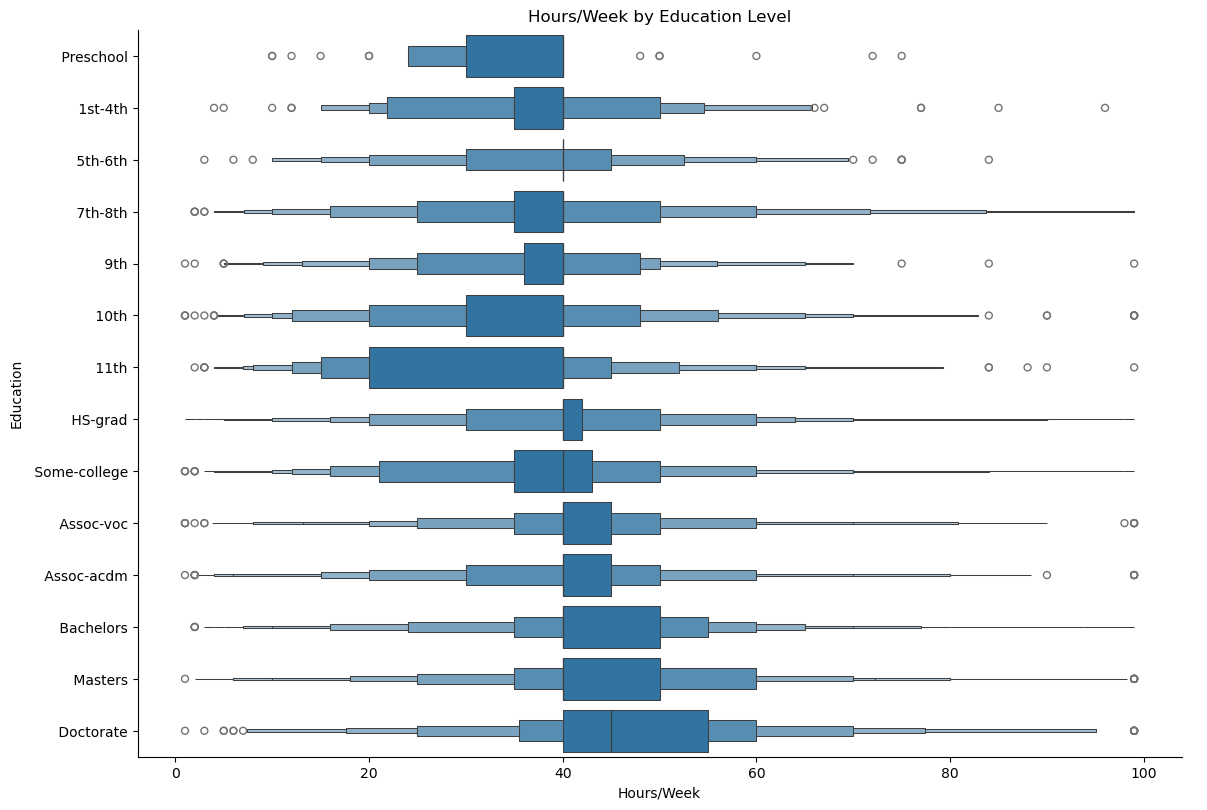

In [81]:
# Extension: Visualize data
import seaborn as sns
import matplotlib.pyplot as plt

# ensure education level is sorted in a logical order
adult["Education"] = pd.Categorical(adult["Education"], categories=[" Preschool", " 1st-4th", " 5th-6th", " 7th-8th", " 9th", " 10th", " 11th", " HS-grad", " Some-college", " Assoc-voc", " Assoc-acdm", " Bachelors", " Masters", " Doctorate"], ordered=True)

# Create a boxplot of "Hours/Week" by "Education"
sns.catplot(data=adult, y="Education", x="Hours/Week", kind="boxen", height=8, aspect=1.5)
plt.title("Hours/Week by Education Level")
plt.show()

- Interesting pattern: 40 hours per week shifts from being the 3rd quartile to the first quartile as education level increases (with 40 hours as median at "some college").